In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.colors as mcolors
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
analysis_df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
analysis_df["zip_code"] = analysis_df["zip_code"].astype(str).str.zfill(5)

# Restrict to the SAME sample the regressions use. Previously this notebook clustered
# the full unfiltered file and handed the gaps to SimpleImputer(strategy='median'),
# which meant ~800 ZIPs with no ACS data at all were pushed to the centroid of every
# predictor and duly grouped together: the largest reported cluster was 69% rows with
# no data. That is an imputation artifact, not a socio-technical typology. It also
# left the cluster table (N=2,552) and the summary-statistics table (N=1,386)
# describing different universes.
_n_before = len(analysis_df)
analysis_df["total_population"] = pd.to_numeric(analysis_df["total_population"], errors="coerce")
analysis_df = analysis_df[
    analysis_df["total_population"].notna() & (analysis_df["total_population"] >= 1000)
]
_core_needed = ["median_household_income", "pct_black", "pct_hispanic", "pct_asian"]
analysis_df = analysis_df.dropna(
    subset=[c for c in _core_needed if c in analysis_df.columns]
).reset_index(drop=True)
print(f"Clustering sample: {len(analysis_df)} ZIPs (from {_n_before}); matches the regression sample.")

df = analysis_df.drop(columns=['zip_code','overlap_area_m2','overlap_share_of_zip',
                      'utility','acronym','Unnamed: 0', 'lat', 'lon',
                      't2m_max_mean_c_2023', 't2m_min_mean_c_2023',
                      't2m_summer_mean_c_2023', "Unnamed: 0.1", 'pop_density_km2',
                      'kwh_annual_total', 'county_geoid', 'county_name', 'plant_capacity_mw'],
            errors='ignore').copy()
print(df.columns)

[9327, 9414, 9416, 9534, 9566, 9570, 9663, 90001, 90002, 90003, 90004, 90005, 90006, 90007, 90008, 90009, 90010, 90011, 90012, 90013, 90014, 90015, 90016, 90017, 90018, 90019, 90020, 90021, 90022, 90023, 90024, 90025, 90026, 90027, 90028, 90029, 90030, 90031, 90032, 90033, 90034, 90035, 90036, 90037, 90038, 90039, 90040, 90041, 90042, 90043, 90044, 90045, 90046, 90047, 90048, 90049, 90050, 90051, 90053, 90054, 90055, 90056, 90057, 90058, 90059, 90060, 90061, 90062, 90063, 90064, 90065, 90066, 90067, 90068, 90069, 90071, 90073, 90074, 90075, 90077, 90078, 90079, 90080, 90082, 90083, 90086, 90089, 90091, 90093, 90094, 90095, 90201, 90204, 90209, 90210, 90211, 90212, 90213, 90220, 90221, 90222, 90223, 90224, 90230, 90231, 90232, 90233, 90239, 90240, 90241, 90242, 90245, 90247, 90248, 90249, 90250, 90251, 90254, 90255, 90260, 90261, 90262, 90263, 90264, 90265, 90266, 90267, 90270, 90271, 90272, 90273, 90274, 90275, 90277, 90278, 90280, 90290, 90291, 90292, 90293, 90294, 90295, 90296, 90301

In [16]:
# safer missing handling
df["utility_type"] = df["utility_type"].fillna("POU")

population = df["total_population"].replace(0, np.nan)

rate_cols = {
    'PV_system_size_DC': ('pv_kw_per_1k', 1000.0),
    'total_chargers': ('chargers_per_1k', 1000.0),
    'zev_count': ('zev_per_1k', 1000.0),
    'storage_capacity_mw': ('storage_mw_per_100k', 100000.0),
    'wind_capacity_mw': ('wind_mw_per_100k', 100000.0),
    'wind_turbine_count': ('turbines_per_100k', 100000.0),
}

for col, (new_name, denom) in rate_cols.items():
    if col in df.columns:
        df[new_name] = df[col] / (population / denom)
        df.drop(columns=[col], inplace=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

cluster_columns = ['UMAP_Cluster','PCA_Cluster','tSNE_Cluster',
'Cluster','RF_Cluster', 'cluster_z_pca', "cluster_z2_tsne", "cluster_z2_umap"]
df = df.drop(columns=[c for c in cluster_columns if c in df.columns], errors='ignore')
df = df.dropna(axis=1, how="all")

categorical_cols = ["utility_type"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[('cat', encoder, categorical_cols)],
    remainder='passthrough'
)

df_encoded = preprocessor.fit_transform(df)
df_encoded = pd.DataFrame(df_encoded, columns=preprocessor.get_feature_names_out())

# single imputation
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df_encoded)

scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(data_imputed)
clustering_data_scaled = pd.DataFrame(clustering_data_scaled, columns=df_encoded.columns)

rename_map = {}
for column in clustering_data_scaled.columns:
    if column[:3] == "cat":
        rename_map[column] = column[5:]
    else:
        rename_map[column] = column[11:]
clustering_data_scaled.rename(columns = rename_map, inplace = True)
stand_rename_map = {
    "cdd65_2023": "Cooling degree days",
    "stand_cdd65_2023": "Standardizde cooling degree days",
    "stand_hdd65_2023": "Standardizde heating degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "median_household_income": "Median household income",
    "log_median_housing_value": "Log median housing value",
    "median_housing_value": "Median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "pv_kw_per_1k": "Solar PV adoption per 1k pop",
    "chargers_per_1k": "EV charger per 1k pop",
    "zev_per_1k": "EV cars per 1k pop",
    "storage_mw_per_100k": "Storage deployment per 1k pop",
    "wind_mw_per_100k": "Wind MW per 100k",
    "turbines_per_100k": "Number of turbines per 100k",
    "utility_type_IOU": "IOU Utility",
    "utility_type_POU": "POU Utility",
    "level1_chargers": "Number of Level 1 chargers",
    "level2_chargers": "Number of Level 2 chargers",
    "dc_fast_chargers": "Number of DC fast chargers",
    "utility_type": "Utility type",
    "total_population": "Total population",
    "area_km2": "Area in km2",
    "t2m_mean_c_2023": "Temp at 2m above ground",
    "ghi_mean_kwh_m2_day_2024": "Global horizontal irradiance",
    "wind_ws50m_mean_2024": "Mean wind speed at 50 m",
}
clustering_data_scaled.rename(columns = stand_rename_map, inplace = True)
print(clustering_data_scaled.describe())
print(clustering_data_scaled.columns)

        IOU Utility   POU Utility  Number of Level 1 chargers  \
count  2.572000e+03  2.572000e+03                2.572000e+03   
mean   9.945388e-17 -3.315129e-17               -2.486347e-17   
std    1.000194e+00  1.000194e+00                1.000194e+00   
min   -1.338886e+00 -7.468894e-01               -6.915238e-02   
25%   -1.338886e+00 -7.468894e-01               -6.915238e-02   
50%    7.468894e-01 -7.468894e-01               -6.915238e-02   
75%    7.468894e-01  1.338886e+00               -6.915238e-02   
max    7.468894e-01  1.338886e+00                3.393348e+01   

       Number of Level 2 chargers  Number of DC fast chargers  \
count                2.572000e+03                2.572000e+03   
mean                 1.105043e-17               -2.762608e-18   
std                  1.000194e+00                1.000194e+00   
min                 -3.749404e-01               -5.967226e-01   
25%                 -1.710484e-01               -2.804055e-01   
50%                 -1.7

In [17]:
X = clustering_data_scaled.drop(columns=cluster_columns, errors="ignore")


def set_up_pca_kmeans(n_components, n_clusters, random_state=77):
    pca = PCA(n_components=n_components, random_state=random_state)
    Z_pca = pca.fit_transform(X)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = kmeans.fit_predict(Z_pca)

    df_viz_pca = X.copy()
    df_viz_pca["cluster_z_pca"] = labels.astype(int)

    print(df_viz_pca["cluster_z_pca"].value_counts().sort_index())

    return {
        "pca": pca,
        "embedding": Z_pca,
        "labels": labels.astype(int),
        "kmeans": kmeans,
        "df_viz": df_viz_pca,
    }

In [18]:
def plot_clusters(Z, labels, centroids=None, title=None):
    plot_df = pd.DataFrame(Z[:, :2], columns=["PC1", "PC2"])
    plot_df["cluster"] = pd.Categorical(labels.astype(int))

    n_clusters = plot_df["cluster"].nunique()
    palette = sns.color_palette("tab10", n_colors=n_clusters)

    plt.figure(figsize=(9, 6))
    ax = sns.scatterplot(
        data=plot_df,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette=palette,
        alpha=0.65,
        s=42,
        linewidth=0.2,
        edgecolor="white"
    )

    if centroids is not None:
        centroids_2d = centroids[:, :2]
        ax.scatter(
            centroids_2d[:, 0],
            centroids_2d[:, 1],
            marker="X",
            s=240,
            c="black",
            linewidth=1.0,
            edgecolor="white",
            label="Centroids"
        )

    # Overall title omitted; the figure caption carries it.
    ax.set_xlabel("Principal component 1")
    ax.set_ylabel("Principal component 2")
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()

In [19]:
"""
Optional clustering methods
"""
tsne2 = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=30)
Z2_tsne = tsne2.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z2_tsne)
df_viz_tsne2 = X.copy()
df_viz_tsne2["cluster_z2_tsne"] = labels
print(df_viz_tsne2["cluster_z2_tsne"].value_counts().sort_index())

umap2 = umap.UMAP(n_neighbors=15, min_dist=0.2, n_components=2, random_state=42)
Z2_umap = umap2.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z2_umap)
df_viz_umap2 = X.copy()
df_viz_umap2["cluster_z2_umap"] = labels
print(df_viz_umap2["cluster_z2_umap"].value_counts().sort_index())

cluster_z2_tsne
0     649
1     838
2    1085
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster_z2_umap
0     729
1     762
2    1081
Name: count, dtype: int64


In [20]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []

pc_options = [2, 3, 5, 8, 10, 12, 15]
k_options = range(2, 9)

for n_pc in pc_options:
    pca = PCA(n_components=n_pc, random_state=42)
    X_pca = pca.fit_transform(X)

    explained_var = pca.explained_variance_ratio_.sum()

    for k in k_options:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)
        ch = calinski_harabasz_score(X_pca, labels)
        db = davies_bouldin_score(X_pca, labels)

        results.append({
            "n_pc": n_pc,
            "k": k,
            "explained_variance": explained_var,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "inertia": kmeans.inertia_
        })

results_df = pd.DataFrame(results)

ranked_results_df = results_df.copy()
ranked_results_df["silhouette_rank"] = ranked_results_df["silhouette"].rank(ascending=False, method="min")
ranked_results_df["calinski_rank"] = ranked_results_df["calinski_harabasz"].rank(ascending=False, method="min")
ranked_results_df["davies_rank"] = ranked_results_df["davies_bouldin"].rank(ascending=True, method="min")
ranked_results_df["explained_rank"] = ranked_results_df["explained_variance"].rank(ascending=False, method="min")
ranked_results_df["complexity_rank"] = (ranked_results_df["n_pc"] + ranked_results_df["k"]).rank(ascending=True, method="min")

ranked_results_df["composite_rank"] = (
    0.35 * ranked_results_df["silhouette_rank"] +
    0.25 * ranked_results_df["calinski_rank"] +
    0.20 * ranked_results_df["davies_rank"] +
    0.10 * ranked_results_df["explained_rank"] +
    0.10 * ranked_results_df["complexity_rank"]
)

ranked_results_df = ranked_results_df.sort_values(
    ["composite_rank", "silhouette", "calinski_harabasz", "davies_bouldin", "n_pc", "k"],
    ascending=[True, False, False, True, True, True]
).reset_index(drop=True)

best_row = ranked_results_df.iloc[0]
best_n_components = int(best_row["n_pc"])
best_n_clusters = int(best_row["k"])

print(f"Selected PCA components: {best_n_components}")
print(f"Selected number of clusters: {best_n_clusters}")
display(ranked_results_df.head(10))

Selected PCA components: 2
Selected number of clusters: 5


,n_pc,k,explained_variance,silhouette,calinski_harabasz,davies_bouldin,inertia,silhouette_rank,calinski_rank,davies_rank,explained_rank,complexity_rank,composite_rank
0,2,5,0.285682,0.528264,2211.524222,0.714496,4627.384143,2.0,2.0,1.0,43.0,6.0,6.30
1,2,7,0.285682,0.536775,2250.410363,0.754612,3284.373364,1.0,1.0,2.0,43.0,12.0,6.50
2,2,6,0.285682,0.522779,2177.149294,0.772681,3924.567338,3.0,4.0,4.0,43.0,9.0,8.05
3,2,8,0.285682,0.517161,2185.606800,0.777945,2953.044838,4.0,3.0,5.0,43.0,15.0,8.95
4,2,4,0.285682,0.505632,1944.940322,0.755526,6287.562967,8.0,5.0,3.0,43.0,4.0,9.35
5,3,6,0.377291,0.514099,1674.338107,0.881805,6374.353908,5.0,7.0,14.0,36.0,12.0,11.10
6,3,5,0.377291,0.506308,1656.874121,0.881619,7585.882604,7.0,8.0,13.0,36.0,9.0,11.55
7,3,8,0.377291,0.512525,1623.479980,0.856219,5001.763966,6.0,9.0,9.0,36.0,19.0,11.65
8,3,4,0.377291,0.502317,1606.267337,0.841447,9445.908017,10.0,11.0,8.0,36.0,6.0,12.05
9,2,3,0.285682,0.461545,1705.051135,0.866464,8839.761764,14.0,6.0,10.0,43.0,2.0,12.90


In [21]:
results_df.to_csv("../outputs/tables/gridsearch_results.csv", index=False)
ranked_results_df.to_csv("../outputs/tables/gridsearch_results_ranked.csv", index=False)

The final PCA/KMeans specification is selected automatically using the grid-search table above.

The notebook ranks each `(n_pc, k)` pair using a weighted composite of:
- higher `silhouette` (higher is better)
- higher `calinski_harabasz`
- lower `davies_bouldin`
- higher `explained_variance`
- lower model complexity (`n_pc + k`)

This keeps the final choice tied to cluster quality while still favoring less complicated solutions when performance is similar. They overall tell you how close together points within a cluster are and how far apart they are from other clusters

cluster_z_pca
0    1220
1     280
2     327
3     489
4     256
Name: count, dtype: int64
Explained variance ratio:
PC1    0.150760
PC2    0.134922
Name: explained_variance_ratio, dtype: float64

Top 10 loadings for PC1:
Median housing value            0.411015
% Bachelor's+                   0.392034
Median household income         0.389040
% Asian                         0.300481
Cooling degree days            -0.295259
Log population density          0.232808
% Hispanic                     -0.193130
Global horizontal irradiance   -0.192119
wind_ws10m_mean_2024            0.189677
Poverty rate                   -0.188826
Name: PC1, dtype: float64

Top 10 loadings for PC2:
Heating degree days              0.417450
Temp at 2m above ground         -0.417133
Total population                -0.324497
Log population density          -0.314454
% Hispanic                      -0.296474
Log annual electricity demand   -0.294748
Global horizontal irradiance    -0.278026
Cooling degree days    

,PC1,PC2,top_pc
Median housing value,0.411015,0.016458,PC1
% Bachelor's+,0.392034,0.035064,PC1
Median household income,0.389040,0.009545,PC1
% Asian,0.300481,0.142164,PC1
Cooling degree days,0.295259,0.257854,PC1
Log population density,0.232808,0.314454,PC2
% Hispanic,0.193130,0.296474,PC2
Global horizontal irradiance,0.192119,0.278026,PC2
wind_ws10m_mean_2024,0.189677,0.009155,PC1
Poverty rate,0.188826,0.040387,PC1



Cluster mean feature profiles (standardized):


,IOU Utility,POU Utility,Number of Level 1 chargers,Number of Level 2 chargers,Number of DC fast chargers,Median household income,Poverty rate,% Bachelor's+,% Black,% Hispanic,...,Mean wind speed at 50 m,Log annual electricity demand,Area in km2,Log population density,Solar PV adoption per 1k pop,EV charger per 1k pop,EV cars per 1k pop,Storage deployment per 1k pop,Wind MW per 100k,Number of turbines per 100k
cluster,,,,,,,,,,,,,,,,,,,,,
0,-1.94,1.94,-0.88,-0.83,-1.15,-0.30,-0.36,-0.34,-0.82,-0.22,...,-0.17,-0.90,-0.49,-0.10,0.19,-0.30,-0.60,0.97,-0.44,-0.57
1,0.82,-0.82,1.17,1.66,0.84,1.82,-1.23,1.70,-0.19,-0.82,...,1.91,-0.54,-0.93,0.74,-0.96,-0.40,0.92,-0.09,-0.67,-0.79
2,0.44,-0.44,-0.63,-0.49,0.07,-1.05,1.67,-1.25,0.93,1.82,...,-0.46,0.82,0.85,0.05,1.05,-0.30,-1.05,-0.86,-0.18,0.36
3,0.60,-0.60,1.27,0.62,1.33,0.20,-0.57,0.40,1.35,0.19,...,-1.04,1.54,-0.95,1.10,-1.34,-0.94,-0.73,-1.30,-0.68,-0.81
4,0.09,-0.09,-0.92,-0.96,-1.09,-0.68,0.50,-0.51,-1.27,-0.96,...,-0.24,-0.92,1.51,-1.80,1.07,1.94,1.46,1.27,1.97,1.81


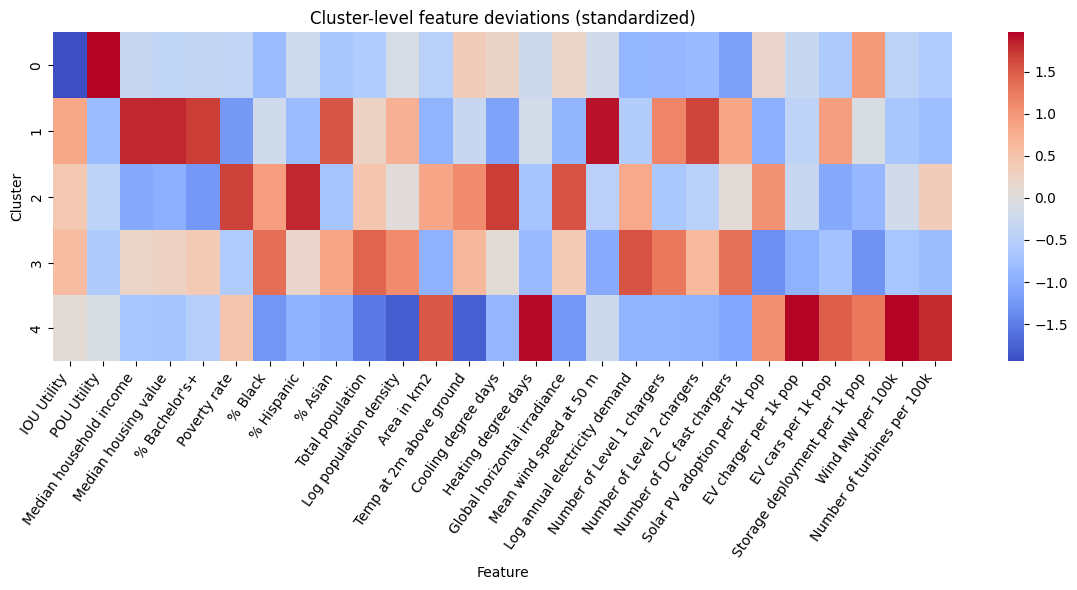

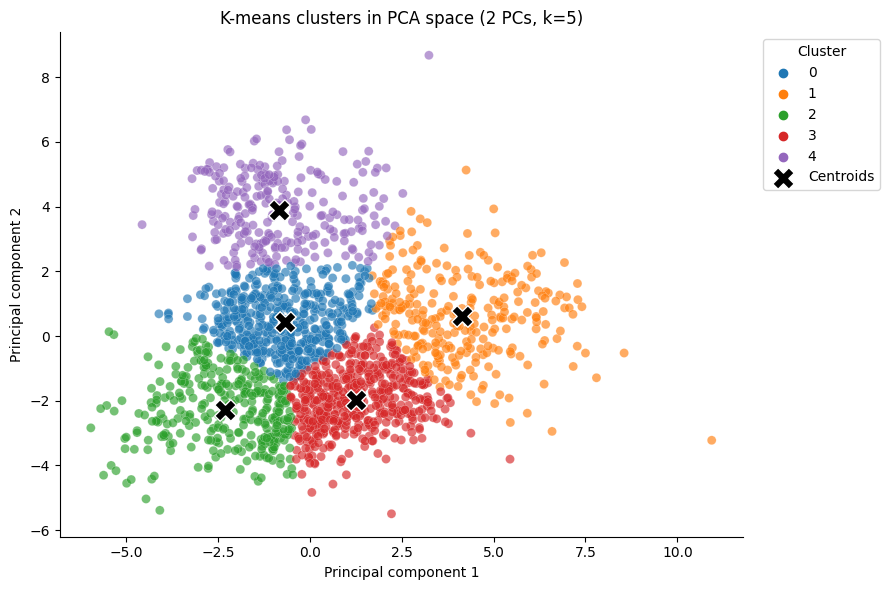

,zip_code,cluster
1176,09327,0
1560,09414,0
1570,09416,0
2010,09534,0
2248,09566,0


In [22]:
def pca_cluster_vis(n_components, n_clusters):
    clustering_result = set_up_pca_kmeans(n_components=n_components, n_clusters=n_clusters)
    pca = clustering_result["pca"]
    df_viz_pca = clustering_result["df_viz"]
    Z = clustering_result["embedding"]
    labels = clustering_result["labels"]
    kmeans = clustering_result["kmeans"]

    loadings = pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=loadings.columns,
        name="explained_variance_ratio"
    )
    print("Explained variance ratio:")
    print(explained)

    top_n = 10
    for pc in loadings.columns:
        s = loadings[pc]
        top = s.abs().sort_values(ascending=False).head(top_n).index
        print(f"\nTop {top_n} loadings for {pc}:")
        print(loadings.loc[top, pc].sort_values(key=np.abs, ascending=False))

    top_features = (
        loadings.abs()
        .assign(top_pc=loadings.abs().idxmax(axis=1))
    )

    print("\nTop contributing features to PCA components:")
    display(top_features.sort_values(by=loadings.columns.tolist(), ascending=False).head(10))

    cluster_labels = pd.Series(labels, index=X.index, name="cluster")
    cluster_means = X.assign(cluster=cluster_labels).groupby("cluster").mean()

    ordered_cols = [
        "IOU Utility",
        "POU Utility",
        "Median household income",
        "Median housing value",
        "% Bachelor's+",
        "Poverty rate",
        "% Black",
        "% Hispanic",
        "% Asian",
        "Total population",
        "Log population density",
        "Area in km2",
        "Temp at 2m above ground",
        "Cooling degree days",
        "Heating degree days",
        "Global horizontal irradiance",
        "Mean wind speed at 50 m",
        "Log annual electricity demand",
        "Number of Level 1 chargers",
        "Number of Level 2 chargers",
        "Number of DC fast chargers",
        "Solar PV adoption per 1k pop",
        "EV charger per 1k pop",
        "EV cars per 1k pop",
        "Storage deployment per 1k pop",
        "Wind MW per 100k",
        "Number of turbines per 100k",
    ]
    ordered_cols = [col for col in ordered_cols if col in cluster_means.columns]

    cluster_scale = cluster_means.std(ddof=0).replace(0, np.nan)
    cluster_means_standard = (cluster_means - cluster_means.mean()) / cluster_scale

    print("\nCluster mean feature profiles (standardized):")
    display(cluster_means_standard.round(2))

    plt.figure(figsize=(12, 6))
    sns.heatmap(cluster_means_standard[ordered_cols], cmap="coolwarm", center=0, annot=False)
    plt.title("Cluster-level feature deviations (standardized)")
    plt.xlabel("Feature")
    plt.xticks(rotation=55, horizontalalignment="right")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    plot_clusters(
        Z,
        labels,
        centroids=kmeans.cluster_centers_,
        title=f"K-means clusters in PCA space ({n_components} PCs, k={n_clusters})"
    )

    return {
        "pca": pca,
        "embedding": Z,
        "labels": labels,
        "df_viz": df_viz_pca,
        "cluster_means_standard": cluster_means_standard,
    }

best_cluster_result = pca_cluster_vis(best_n_components, best_n_clusters)

cluster_assignments = (
    analysis_df[["zip_code"]]
    .assign(cluster=best_cluster_result["labels"].astype(int))
    .drop_duplicates(subset="zip_code")
    .sort_values("zip_code")
)
cluster_assignments.to_csv("../outputs/tables/pca_kmeans_cluster_assignments.csv", index=False)
display(cluster_assignments.head())

Choropleth map of the selected California ZCTA clusters

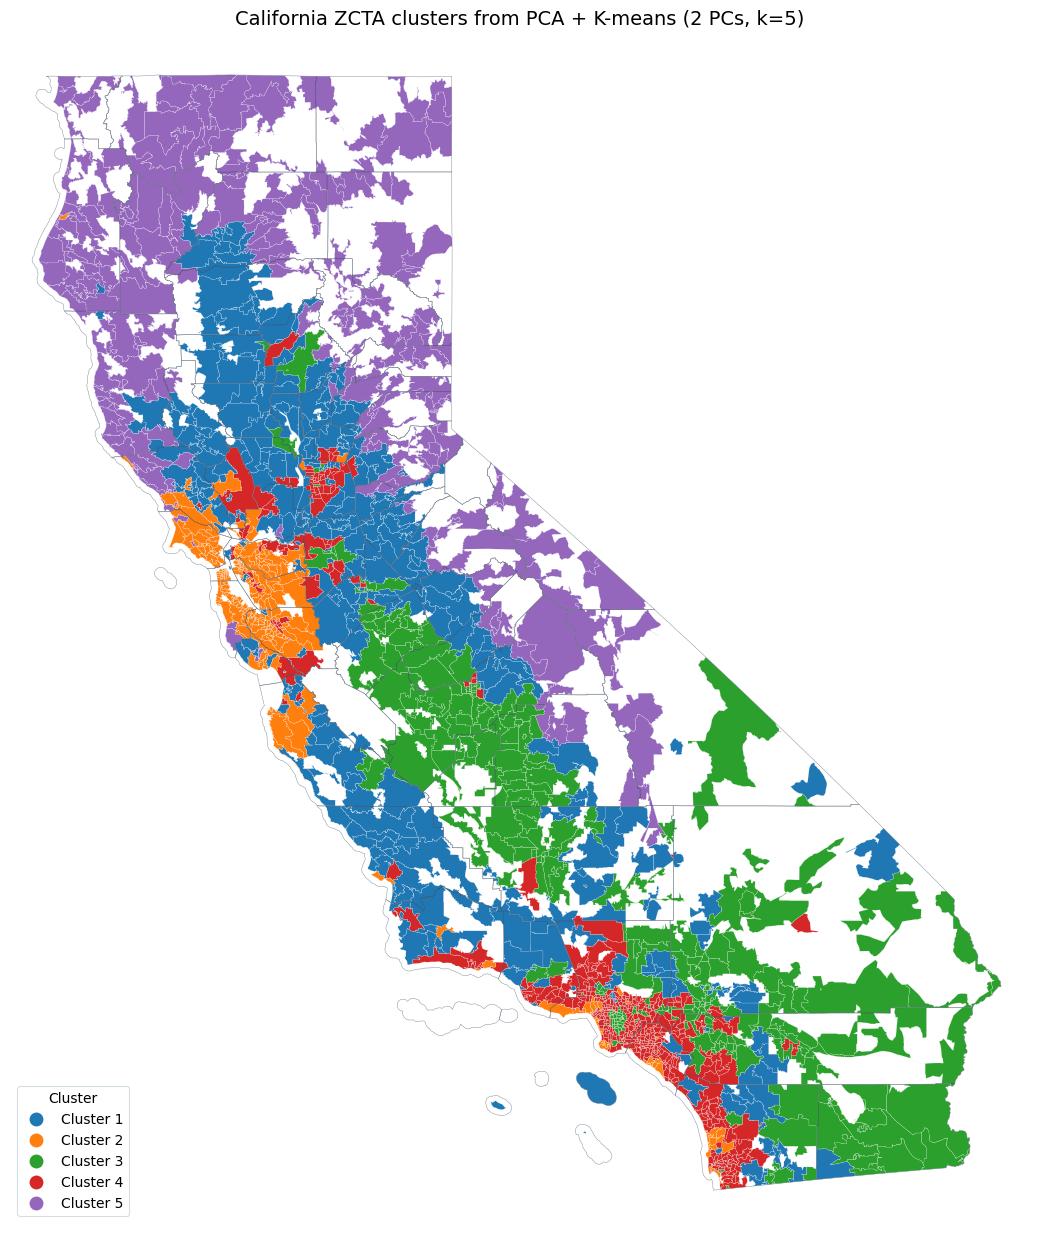

Saved choropleth to ../outputs/figures/cluster_choropleth_map.png


In [23]:
zcta_path = Path("../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp")
county_path = Path("../data/raw/boundaries/tl_2023_us_county/tl_2023_us_county.shp")
output_path = Path("../outputs/figures/cluster_choropleth_map.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

zcta_gdf = gpd.read_file(zcta_path)[["ZCTA5CE20", "geometry"]].rename(columns={"ZCTA5CE20": "zip_code"})
zcta_gdf["zip_code"] = zcta_gdf["zip_code"].astype(str).str.zfill(5)

map_gdf = zcta_gdf.merge(cluster_assignments, on="zip_code", how="inner")
cluster_order = sorted(map_gdf["cluster"].unique())
cluster_label_map = {cluster: f"Cluster {cluster + 1}" for cluster in cluster_order}
map_gdf["cluster_label"] = pd.Categorical(
    map_gdf["cluster"].map(cluster_label_map),
    categories=[cluster_label_map[c] for c in cluster_order],
    ordered=True,
)

ca_counties = gpd.read_file(county_path)
if "STATEFP" in ca_counties.columns:
    ca_counties = ca_counties.loc[ca_counties["STATEFP"] == "06"]
ca_counties = ca_counties.to_crs(map_gdf.crs)

palette = sns.color_palette("tab10", n_colors=len(cluster_order))
cmap = mcolors.ListedColormap(palette.as_hex())

fig, ax = plt.subplots(1, 1, figsize=(10.5, 12.5), facecolor="none")
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
map_gdf.plot(
    column="cluster_label",
    categorical=True,
    cmap=cmap,
    linewidth=0.12,
    edgecolor="white",
    legend=True,
    legend_kwds={"title": "Cluster", "loc": "lower left"},
    ax=ax,
)
ca_counties.boundary.plot(ax=ax, color="#475569", linewidth=0.35, alpha=0.65)

xmin, ymin, xmax, ymax = map_gdf.total_bounds
xpad = (xmax - xmin) * 0.03
ypad = (ymax - ymin) * 0.03
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)
ax.axis("off")

legend = ax.get_legend()
if legend is not None:
    legend.set_frame_on(True)
    legend.get_frame().set_edgecolor("#CBD5E1")
    legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print(f"Saved choropleth to {output_path}")